# Misspecified Symmetry Priors: 1D Sensitivity Analysis

This notebook extends the synthetic 1D conditional-expectation/cCDF experiment to analyze **symmetry-prior misspecification**.

We focus first on the **extrinsic misspecification** setting (marginal $P_X$ bias):
- true data-generating process is reflection-symmetric under $\mathbb{G}=\mathbb{C}_2$,
- but the empirical training distribution is biased toward one coset (here, mostly $x>0$),
- evaluation is done on the full support ($x<0$ and $x>0$).

Following the symmetry-aware perspective, we compare:
1. `NCP` (symmetry-agnostic architecture)
2. `eNCP` (symmetry encoded as architectural prior)

**Main outputs for this section**
1. Quantile-prediction plots across the full x-range.
2. Left-vs-right side error decomposition:
   - coverage error,
   - CI size,
   - conditional-expectation MAE.

The second misspecification mode (violations in $P_{Y|X}$) is scaffolded at the end as future work.


## 1. Imports and Setup

Training/checkpoint internals are hidden through shared helper functions in `paper/examples/utils.py`, while still showing live training curves during model fitting.


In [34]:
%load_ext autoreload
%autoreload 2

import os
import pathlib
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import escnn

from symm_learning.models import MLP, iMLP
from symm_rep_learn.inference import ENCPConditionalCDF, NCPConditionalCDF
from symm_rep_learn.models import ENCP
from symm_rep_learn.models.neural_conditional_probability.ncp import NCP
from symm_rep_learn.nn.layers import ResidualEncoder
from torch.utils.data import DataLoader, TensorDataset

# Paths
ROOT = pathlib.Path(os.getcwd())
WS_PATH = ROOT.parent.parent.parent
PLOT_PATH = ROOT / "plots"
PLOT_PATH.mkdir(parents=True, exist_ok=True)
CHECKPOINT_PATH = ROOT / "checkpoints"
CHECKPOINT_PATH.mkdir(parents=True, exist_ok=True)
METRICS_PATH = PLOT_PATH / "metrics"
METRICS_PATH.mkdir(parents=True, exist_ok=True)

# Imports from repository
sys.path.append(str(WS_PATH))

from paper.examples.utils import (
    dataframe_to_markdown,
    fit_or_load_ncp_like,
    make_condexp_1d_dataset,
    make_positive_bias_train_val_split,
    plot_saved_training_curves_panel,
    split_x_side_masks,
    true_condexp_1d,
)
from paper.examples.conditional_expectation_regression.plotting import (
    plot_expectations_with_quantiles,
    scatter_with_density,
)


SEED = 10
np.random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
plt.style.use("seaborn-v0_8-notebook")
FIG_SIZE = (5.5, 3)

# Data sizes
N = 20_000
TRAIN_POS_RATIO = 0.85  # split ratio inside x>0 subset for train/val
EVAL_N = 50_000

# Training hyperparameters
EMBEDDING_DIM = 32
BATCH_SIZE = 2024
EPOCHS = 2500
CHECK_EVERY = 10
PATIENCE = 50
PLOT_FREQ = 100
NCP_LR = 2e-3

print(f"Device: {DEVICE}")
print(f"Workspace root: {WS_PATH}")
print(f"Experiment root: {ROOT}")

# Symmetry representations used for symmetry-aware standardization
G = escnn.group.CyclicGroup(2)
x_rep = G.irrep(1)
y_rep = G.trivial_representation


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Device: cuda
Workspace root: /home/danfoa/Projects/symm_rep_learn
Experiment root: /home/danfoa/Projects/symm_rep_learn/paper/examples/misspecified_sensitivity_analysis


## 2. Extrinsic Misspecification of Marginal Invariance
### 2.1 Problem Definition, Sampling Bias, and Summary Conclusions

<b>Extrinsic symmetry misspecification.</b>
Following the correct/incorrect/extrinsic symmetry misspecification taxonomy of [Wang et al. (2023)](https://proceedings.neurips.cc/paper_files/paper/2023/hash/7dc7793c89b93887e126a86f22ef63c6-Abstract-Conference.html), this experiment studies the <b>extrinsic</b> case, in which the the $\mathbb{G}$-invariance of the marginal distribution $P_X$ is violated in the empirical training/validation/test distributions. In this scenario, the conditional distribution $P_{Y|X}$ is assumed to comply with the $\mathbb{G}$-invariance prior.

We consider $\mathcal{X}\subset\mathbb{R}$ with reflection symmetry
$\mathbb{G}=\mathbb{C}_2=\{e,g_r\}$, where
$g_r\triangleright_{\mathcal{X}}x=-x$ and $g_r\triangleright_{\mathcal{Y}}y=y$.
Hence the conditional law $P_{Y \mid X}$ is $\mathbb{C}_2$-invariant.

In this scenario extrinsic misspecification implies that the training/validation/testing empirical samplings from $P_X$ are biased toward one coset/space (here, mostly $x>0$). Hence, as depicted below, although the conditional distribution remains invariant, the NNs will be trained only on one side of the support, and never see in practice the symetry transformed conditionings. 

<div align="center">
  <img src="plots/misspec_px_protocol.png" width="70%" />
</div>

<b>Summary conclusions.</b>

As depicted below, enforcing the NN embedding of $\mathcal{X}$ to be $\mathbb{C}_2$-equivariant does not impact the performance of the model on the nominal support ($x>0$). However, it endows the model with prediction capabilities in the out-of-distribution (o.o.d) region ($x<0$). Hence, the symmetry priors act as a regularization of the model improving generalization. In practice, as equivariance constraints reduce the number of trainable parameters in the NN, its expected for eNCP to underperform NCP on the nominal support, since NCP uses more parameters to fit support of the training distribution. However, in this experiment we dont see such a degradation.
<div align="center">
  <img src="plots/misspec_px_quantile_predictions.png" width="82%" />
</div>

As depicted below, the side-wise decomposition (log-scale) confirms that the equivariant prior helps on OOD support without materially hurting nominal support.

<div align="center">
  <img src="plots/misspec_px_sidewise_error_decomposition.png" width="82%" />
</div>

<b>References:</b>

Wang, D., Zhu, X., Park, J. Y., Jia, M., Su, G., Platt, R., & Walters, R. (2023).
<i>A general theory of correct, incorrect, and extrinsic equivariance</i>.
<i>Advances in Neural Information Processing Systems, 36</i>, 40006-40029.
<a href="https://proceedings.neurips.cc/paper_files/paper/2023/hash/7dc7793c89b93887e126a86f22ef63c6-Abstract-Conference.html">Abstract</a>,
<a href="https://proceedings.neurips.cc/paper_files/paper/2023/file/7dc7793c89b93887e126a86f22ef63c6-Paper-Conference.pdf">PDF</a>.


In [35]:
# Full dataset (used only as source for biased train/val extraction)
x_full, y_full = make_condexp_1d_dataset(n=N, seed=SEED)

# Biased train/val from x > 0 only; returns standardized tensors using train statistics
split = make_positive_bias_train_val_split(
    x_full,
    y_full,
    train_ratio=TRAIN_POS_RATIO,
    seed=SEED,
    threshold=0.0,
    x_rep=x_rep,
    y_rep=y_rep,
)

x_tr, y_tr = split["x_tr"], split["y_tr"]
x_val, y_val = split["x_val"], split["y_val"]
x_tr_c, y_tr_c = split["x_tr_c"], split["y_tr_c"]
x_val_c, y_val_c = split["x_val_c"], split["y_val_c"]
x_mean, x_std = split["x_mean"], split["x_std"]
y_mean, y_std = split["y_mean"], split["y_std"]

# Full-support evaluation dataset
x_eval, y_eval = make_condexp_1d_dataset(n=EVAL_N, seed=SEED + 10_000)
x_eval_c = (x_eval - x_mean) / x_std
y_eval_c = (y_eval - y_mean) / y_std

train_dl = DataLoader(TensorDataset(x_tr_c, y_tr_c), batch_size=BATCH_SIZE, shuffle=True)
val_dl = DataLoader(TensorDataset(x_val_c, y_val_c), batch_size=BATCH_SIZE, shuffle=False)

left_ratio_train = float((x_tr.reshape(-1) < 0).float().mean().item())
left_ratio_eval = float((x_eval.reshape(-1) < 0).float().mean().item())
print(f"Train size: {x_tr.shape[0]:,} | Val size: {x_val.shape[0]:,}")
print(f"Left-side ratio in train: {left_ratio_train:.4f} (expected ~0.0)")
print(f"Left-side ratio in full eval: {left_ratio_eval:.4f} (expected ~0.5)")


Train size: 8,449 | Val size: 1,492
Left-side ratio in train: 0.0000 (expected ~0.0)
Left-side ratio in full eval: 0.4981 (expected ~0.5)


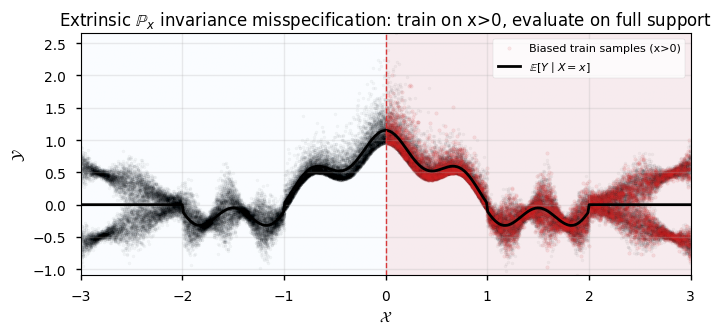

In [36]:
fig, ax = plt.subplots(figsize=(FIG_SIZE[0] * 1.3, FIG_SIZE[1] * 1.15))

# Background: full-support data distribution
scatter_with_density(x_eval.numpy(), y_eval.numpy(), ax=ax, alpha_points=0.03, s=5)

# Overlay: biased train samples (x>0 only)
ax.scatter(x_tr.numpy(), y_tr.numpy(), s=6, color="tab:red", alpha=0.10, label="Biased train samples (x>0)")

# True conditional expectation curve
x_grid_raw = torch.linspace(-3.0, 3.0, 500).reshape(-1, 1)
y_true_raw = true_condexp_1d(x_grid_raw)
ax.plot(x_grid_raw.numpy(), y_true_raw.numpy(), color="black", lw=2.0, label=r"$\mathbb{E}[Y\mid X=x]$")

# Visual cue of sampled training half-space
ax.axvspan(0.0, 3.0, color="tab:red", alpha=0.08, zorder=0)
ax.axvline(0.0, color="tab:red", ls="--", lw=1.0, alpha=0.9)

ax.set_title(r"Extrinsic $\mathbb{P}_x$ invariance misspecification: train on x>0, evaluate on full support")
ax.set_xlabel(r"$\mathcal{X}$")
ax.set_ylabel(r"$\mathcal{Y}$")
ax.set_xlim(-3.0, 3.0)
ax.grid(True, alpha=0.25)
ax.legend(fontsize=8, loc="upper right")
fig.tight_layout()
fig.savefig(PLOT_PATH / "misspec_px_protocol.png", dpi=220)
plt.show()


### 2.2 Model Training Under Biased Support

<div style="margin-left: 1.25em;">
We compare <code>NCP</code> (symmetry-agnostic) against <code>eNCP</code> (symmetry-constrained)
with matched backbone size and optimization settings. This isolates the effect of the symmetry prior
under marginal-support misspecification.
</div>


Loading model from checkpoint: /home/danfoa/Projects/symm_rep_learn/paper/examples/misspecified_sensitivity_analysis/checkpoints/ncp_px_extrinsic_model_N=20000_seed=10.pth
Loaded - best val objective: -2.72302


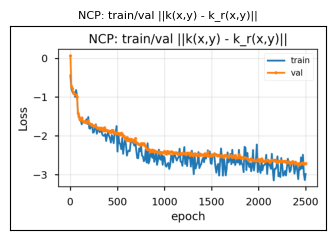

Loading model from checkpoint: /home/danfoa/Projects/symm_rep_learn/paper/examples/misspecified_sensitivity_analysis/checkpoints/encp_px_extrinsic_model_N=20000_seed=10.pth
Loaded - best val objective: -3.09575


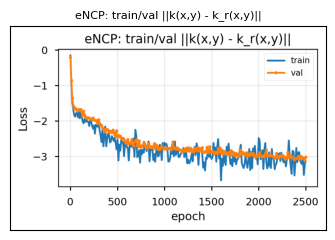

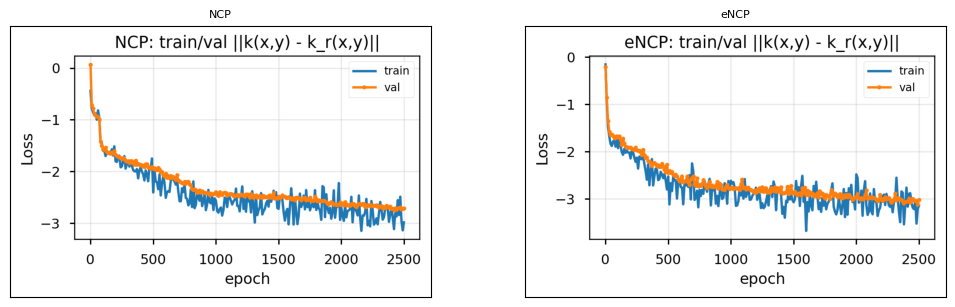

In [37]:
# Reflection symmetry group C2 representations are defined in setup and reused here.

BATCH_NORM = False
ORTH_REG = 0.01
CENTERING_REG = 0.01
MOMENTUM = 0.99


def make_ncp_model():
    return NCP(
        embedding_x=ResidualEncoder(
            MLP(
                in_dim=1,
                out_dim=EMBEDDING_DIM,
                hidden_units=[EMBEDDING_DIM * 2] * 2,
                activation=torch.nn.ELU(),
                bias=True,
                batch_norm=BATCH_NORM,
            ),
            in_dim=1,
        ),
        embedding_y=ResidualEncoder(
            MLP(
                in_dim=1,
                out_dim=EMBEDDING_DIM,
                hidden_units=[EMBEDDING_DIM * 2] * 2,
                activation=torch.nn.ELU(),
                bias=True,
                batch_norm=BATCH_NORM,
            ),
            in_dim=1,
        ),
        embedding_dim_x=EMBEDDING_DIM + 1,
        embedding_dim_y=EMBEDDING_DIM + 1,
        orth_reg=ORTH_REG,
        centering_reg=CENTERING_REG,
        momentum=MOMENTUM,
    ).to(DEVICE)


def make_encp_model():
    rep_tag = len(G.representations)
    x_embedding = iMLP(
        in_rep=x_rep,
        out_dim=EMBEDDING_DIM,
        hidden_units=[EMBEDDING_DIM * 2] * 2,
        activation=torch.nn.ELU(),
        bias=True,
    )
    y_embedding = iMLP(
        in_rep=y_rep,
        out_dim=EMBEDDING_DIM,
        hidden_units=[EMBEDDING_DIM * 2] * 2,
        activation=torch.nn.ELU(),
        bias=True,
    )
    x_embedding.out_rep.name = f"x_lat_rep_misspec_{rep_tag}"
    y_embedding.out_rep.name = f"y_lat_rep_misspec_{rep_tag}"
    return ENCP(
        embedding_x=x_embedding,
        embedding_y=y_embedding,
        orth_reg=ORTH_REG,
        centering_reg=CENTERING_REG,
        momentum=MOMENTUM,
    ).to(DEVICE)


checkpoint_meta = {
    "seed": SEED,
    "embedding_dim": EMBEDDING_DIM,
    "batch_size": BATCH_SIZE,
    "misspecification": "Px_extrinsic_positive_halfspace",
}

ncp = make_ncp_model()
encp = make_encp_model()

ncp_optimizer = torch.optim.Adam(ncp.parameters(), lr=NCP_LR)
encp_optimizer = torch.optim.Adam(encp.parameters(), lr=NCP_LR)

ncp_checkpoint = CHECKPOINT_PATH / f"ncp_px_extrinsic_model_N={N:d}_seed={SEED:d}.pth"
encp_checkpoint = CHECKPOINT_PATH / f"encp_px_extrinsic_model_N={N:d}_seed={SEED:d}.pth"

best_ncp_state, best_ncp_val = fit_or_load_ncp_like(
    model=ncp,
    train_loader=train_dl,
    val_loader=val_dl,
    optimizer=ncp_optimizer,
    checkpoint_path=ncp_checkpoint,
    device=DEVICE,
    train_epochs=EPOCHS,
    check_every=CHECK_EVERY,
    patience=PATIENCE,
    plot_freq=PLOT_FREQ,
    desc="Training NCP (extrinsic Px)",
    plot_title="NCP: train/val ||k(x,y) - k_r(x,y)||",
    checkpoint_meta=checkpoint_meta,
)

best_encp_state, best_encp_val = fit_or_load_ncp_like(
    model=encp,
    train_loader=train_dl,
    val_loader=val_dl,
    optimizer=encp_optimizer,
    checkpoint_path=encp_checkpoint,
    device=DEVICE,
    train_epochs=EPOCHS,
    check_every=CHECK_EVERY,
    patience=PATIENCE,
    plot_freq=PLOT_FREQ,
    desc="Training eNCP (extrinsic Px)",
    plot_title="eNCP: train/val ||k(x,y) - k_r(x,y)||",
    checkpoint_meta=checkpoint_meta,
)

ncp.load_state_dict(best_ncp_state)
encp.load_state_dict(best_encp_state)
ncp.eval()
encp.eval()

fig_curves, _ = plot_saved_training_curves_panel(
    [("NCP", ncp_checkpoint), ("eNCP", encp_checkpoint)],
    figsize=(FIG_SIZE[0] * 1.9, FIG_SIZE[1] * 1.05),
)
plt.show()


### 2.3 Confidence Intervals on Full Support

<div style="margin-left: 1.25em;">
We estimate cCDFs and extract confidence intervals (CIs) for both models over the full $x$ range.
The boundary $x=0$ separates nominal support ($x>0$) from out-of-distribution support ($x<0$)
under the training protocol.
</div>


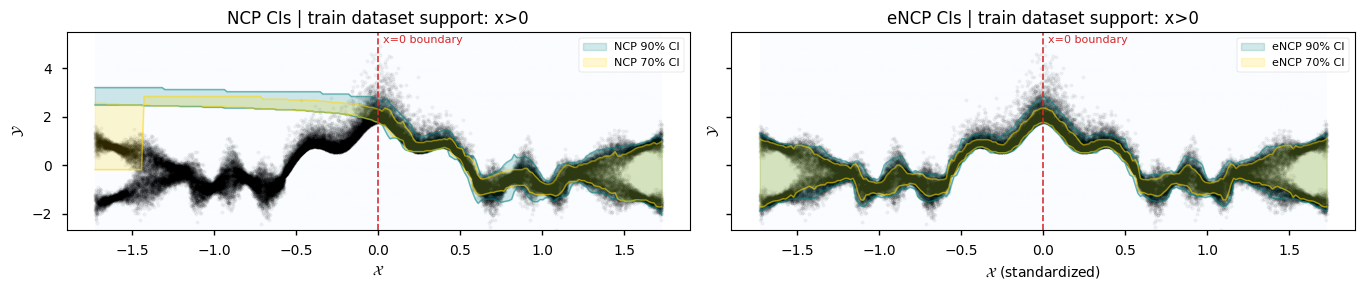

In [38]:
# Fit linear decoders h(y) -> y (standardized)
dec_dl = DataLoader(TensorDataset(y_tr_c, y_tr_c), batch_size=BATCH_SIZE, shuffle=False)
ncp_lin_decoder = ncp.fit_linear_decoder(train_dataloader=dec_dl)
encp_lin_decoder = encp.fit_linear_decoder(train_dataloader=dec_dl)

# cCDF estimators
ccdf_kwargs = dict(random_state=int(SEED), subsample=None, u_eps=1e-5, output_distribution="normal")
ncp_ccdf = NCPConditionalCDF(
    model=ncp,
    y_train=y_tr_c,
    support_discretization_points=200,
    support_strategy="quantile_transformer",
    discretizer_kwargs=ccdf_kwargs,
)
encp_ccdf = ENCPConditionalCDF(
    model=encp,
    y_train=y_tr_c,
    y_rep=y_rep,
    support_discretization_points=200,
    support_strategy="quantile_transformer",
    discretizer_kwargs=ccdf_kwargs,
)

# Full x-grid in raw and standardized coordinates
x_grid = torch.linspace(-3.0, 3.0, 220).reshape(-1, 1)
x_grid_c = (x_grid - x_mean) / x_std
x_grid_c_np = x_grid_c.numpy().ravel()

quantile_levels = [0.10, 0.30]
model_specs = [("NCP", ncp_ccdf), ("eNCP", encp_ccdf)]

fig, axs = plt.subplots(1, 2, figsize=(FIG_SIZE[0] * 2.5, FIG_SIZE[1] ), sharex=True, sharey=True)
axs = np.atleast_1d(axs)

x0_c = float(((torch.tensor([[0.0]]) - x_mean) / x_std).item())

for ax, (model_name, ccdf_model) in zip(axs, model_specs):
    q_bands = {}
    for alpha in quantile_levels:
        q_lo, q_up = ccdf_model.conditional_quantiles(x_cond=x_grid_c, alpha=alpha)
        q_bands[f"{model_name} {(1 - alpha) * 100:.0f}% CI"] = (np.asarray(q_lo).ravel(), np.asarray(q_up).ravel())

    plot_expectations_with_quantiles(
        x_train=x_eval_c.numpy().ravel(),
        y_train=y_eval_c.numpy().ravel(),
        x_grid=x_grid_c_np,
        expectations=None,
        est_quantiles=q_bands,
        quantile_colors=["teal", "gold"],
        true_quantiles=None,
        ax=ax,
    )
    ax.axvline(x0_c, color="tab:red", ls="--", lw=1.2, alpha=0.95)
    ax.text(x0_c + 0.03, ax.get_ylim()[1] * 0.92, "x=0 boundary", color="tab:red", fontsize=8)
    ax.set_title(f"{model_name} CIs | train dataset support: x>0")

axs[-1].set_xlabel(r"$\mathcal{X}$ (standardized)")
fig.tight_layout()
fig.savefig(PLOT_PATH / "misspec_px_quantile_predictions.png", dpi=220)
plt.show()


### 2.4 Side-wise Error Decomposition

We report metrics on three supports:
- `train support` ($x>0$): nominal in-support regime,
- `ood support` ($x<0$): out-of-distribution regime,
- `full support`: combined regime.

<div style="margin-left: 1.25em;">
Metrics include mean CI coverage error, mean CI size, and conditional-expectation MAE,
aggregated over confidence levels.
</div>


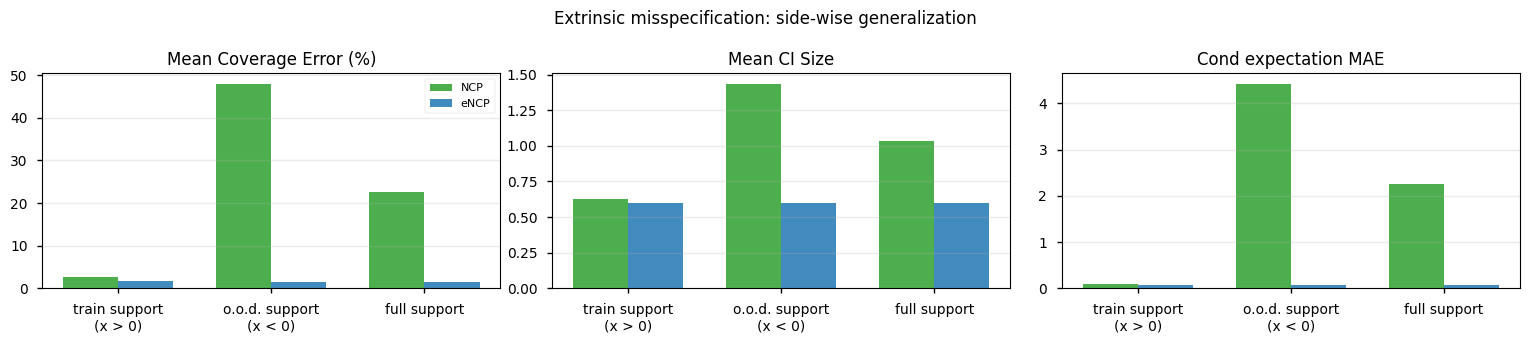

In [39]:
@torch.no_grad()
def coverage_and_size_for_subset(ccdf_model, x_subset_c, y_subset_c, alpha, batch_size=BATCH_SIZE):
    dl = DataLoader(TensorDataset(x_subset_c, y_subset_c), batch_size=batch_size, shuffle=False)
    cov, size, n = 0.0, 0.0, 0
    for xb, yb in dl:
        q_lo, q_up = ccdf_model.conditional_quantiles(x_cond=xb, alpha=alpha)
        q_lo = torch.as_tensor(q_lo, dtype=torch.float32)
        q_up = torch.as_tensor(q_up, dtype=torch.float32)
        inside = ((q_lo <= yb) & (yb <= q_up)).float().mean()
        seg = (q_up - q_lo).abs().mean()
        cov += float(inside.item())
        size += float(seg.item())
        n += 1
    return cov / max(n, 1), size / max(n, 1)


@torch.no_grad()
def condexp_mae_for_subset(model, lin_decoder, x_subset_c, y_true_subset_c):
    pred = model.conditional_expectation(x=x_subset_c.to(DEVICE), hy2zy=lin_decoder).detach().cpu()
    return float((pred - y_true_subset_c).abs().mean().item())


side_masks = split_x_side_masks(x_eval)
alpha_values = [0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90]
model_ccdfs = {"NCP": ncp_ccdf, "eNCP": encp_ccdf}

rows_alpha = []
for alpha in alpha_values:
    desired = (1.0 - alpha) * 100.0
    for model_name, ccdf_model in model_ccdfs.items():
        for side_name, mask in side_masks.items():
            x_sub = x_eval_c[mask]
            y_sub = y_eval_c[mask]
            cov, ci_size = coverage_and_size_for_subset(ccdf_model, x_sub, y_sub, alpha)
            rows_alpha.append(
                {
                    "model": model_name,
                    "side": side_name,
                    "alpha": float(alpha),
                    "desired_coverage_pct": float(desired),
                    "coverage_pct": float(cov * 100.0),
                    "coverage_error_pct": float(abs(cov * 100.0 - desired)),
                    "ci_size": float(ci_size),
                    "num_samples": int(mask.sum().item()),
                }
            )

df_side_alpha = pd.DataFrame(rows_alpha)

# Conditional expectation MAE by side
z_eval_true_c = (true_condexp_1d(x_eval) - y_mean) / y_std
rows_mae = []
for model_name, model, lin_dec in [
    ("NCP", ncp, ncp_lin_decoder),
    ("eNCP", encp, encp_lin_decoder),
]:
    for side_name, mask in side_masks.items():
        mae = condexp_mae_for_subset(model, lin_dec, x_eval_c[mask], z_eval_true_c[mask])
        rows_mae.append({"model": model_name, "side": side_name, "condexp_mae": mae, "num_samples": int(mask.sum().item())})

df_side_mae = pd.DataFrame(rows_mae)

# Aggregate summary
df_side_summary = (
    df_side_alpha.groupby(["model", "side"], as_index=False)
    .agg(
        mean_coverage_error_pct=("coverage_error_pct", "mean"),
        mean_ci_size=("ci_size", "mean"),
    )
    .merge(df_side_mae, on=["model", "side"], how="left")
)

alpha_csv = METRICS_PATH / f"misspec_px_side_alpha_metrics_N={N:d}_seed={SEED:d}.csv"
summary_csv = METRICS_PATH / f"misspec_px_side_summary_N={N:d}_seed={SEED:d}.csv"
df_side_alpha.to_csv(alpha_csv, index=False)
df_side_summary.to_csv(summary_csv, index=False)

# Compact comparison plots for side-wise summary
plot_sides = ["right", "left", "full"]
plot_side_labels = ["train support\n(x > 0)", "o.o.d. support\n(x < 0)", "full support"]
models = ["NCP", "eNCP"]
colors = {"NCP": "tab:green", "eNCP": "tab:blue"}

fig, axs = plt.subplots(1, 3, figsize=(FIG_SIZE[0] * 2.8, FIG_SIZE[1] * 1.15), sharex=True)
axs = np.atleast_1d(axs)
x = np.arange(len(plot_sides), dtype=float)
width = 0.36

for m_idx, model_name in enumerate(models):
    df_m = df_side_summary[df_side_summary["model"] == model_name].set_index("side").reindex(plot_sides)
    xpos = x + (m_idx - (len(models) - 1) / 2) * width

    axs[0].bar(xpos, df_m["mean_coverage_error_pct"].to_numpy(), width=width, color=colors[model_name], alpha=0.85, label=model_name)
    axs[1].bar(xpos, df_m["mean_ci_size"].to_numpy(), width=width, color=colors[model_name], alpha=0.85, label=model_name)
    axs[2].bar(xpos, df_m["condexp_mae"].to_numpy(), width=width, color=colors[model_name], alpha=0.85, label=model_name)

axs[0].set_title("Mean Coverage Error (%)")
axs[1].set_title("Mean CI Size")
axs[2].set_title("Cond expectation MAE")


for ax in axs:
    ax.set_xticks(x)
    ax.set_xticklabels(plot_side_labels)
    # ax.set_yscale("log")
    ax.grid(True, axis="y", alpha=0.25)

axs[0].legend(fontsize=8)
fig.suptitle("Extrinsic misspecification: side-wise generalization")
fig.tight_layout()
fig.savefig(PLOT_PATH / "misspec_px_sidewise_error_decomposition.png", dpi=220)
plt.show()


### 2.5 Section Wrap-up

The detailed computations and plots in Sections 2.2-2.4 support the summary in Section 2.1:
- no meaningful performance penalty on nominal support ($x>0$),
- improved robustness when OOD conditioning values ($x<0$) appear.

## 3. Next Section: Conditional Misspecification of $P_{Y\mid X}$

Planned extension:
- violate the symmetry structure of $P_{Y\mid X}$ while controlling $P_X$, then repeat the same CI and side-wise diagnostics.
